Nesse notebook vamos fazer a EDA (análise exploratória) para verificar os dados que geramos e já tirar algumas métricas para o dashboard.

In [59]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from utils.io.parquet import load_parquet
from utils.wfs_geosampa import GeoSampaWFSFetcher
from utils.io.static import save_static_binary_file, save_img
from config import OUTPUT_DIR

In [60]:
df = load_parquet('df_final.parquet', subfolder='microdados_lotes_com_zoneamento', gdf=False, output=True)

In [61]:
df.head()

,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,area_interseccao,id_perimetro_zoneamento,percentual_interseccao,sql
0,287,005,0010,00,ZMa,2024,244.952910,244.952910,537870,100.0,287.005.0010
1,287,002,0022,00,ZMa,2024,262.557244,262.557244,537875,100.0,287.002.0022
2,287,004,0008,00,ZMa,2024,172.164871,172.164871,537866,100.0,287.004.0008
3,287,005,0003,00,ZMa,2024,253.488401,253.488401,537870,100.0,287.005.0003
4,287,003,0008,00,ZMa,2024,250.609037,250.609037,537867,100.0,287.003.0008


Identificando lotes com mais de um zoneamento

Os lotes com mais de um zoneamento são aqueles que:
1. o SQL aparece mais de uma vez na tabela (porque intersectou com mais de um perímetro)
2. pelo menos 2 percentuais de intersecção são significativos (tem caso que é uma intersecção tão pequena que o percentual dá o% a 3 dígitos de significância)
3. O zoneamento em si dos perímetros intersectados é diferente (porque não faz diferença se ele intersecta dois perímetros mas os dois são ZER-1 por exemplo)

In [62]:
duplicados = df[df['sql'].duplicated(keep=False)].reset_index(drop=True).sort_values(by='sql')

In [63]:
duplicados['sql'].nunique()

90561

In [64]:
prop_duplicados = duplicados['sql'].nunique()/df['sql'].nunique()
percent_duplicados = round(prop_duplicados * 100, 2)
percent_duplicados

5.49

Vou adicionando umas métricas em um dicionario para depois salvar como JSON e abrir no dashboard.

Os dados vou salvando em parquet para ficar melhor de abrir

In [65]:
metricas_dashboard = {
    'percent_lotes_mais_um_zona' : percent_duplicados
}

In [66]:
duplicados.columns

Index(['cd_setor_fiscal', 'cd_quadra_fiscal', 'cd_lote', 'cd_condominio',
       'cd_zoneamento_perimetro', 'an_legislacao_zoneamento', 'area_pol_lote',
       'area_interseccao', 'id_perimetro_zoneamento', 'percentual_interseccao',
       'sql'],
      dtype='str')

In [67]:
duplicados_por_sql = duplicados.groupby('sql')['percentual_interseccao'].agg(['count', 'mean', 'min', 'max']).reset_index()

In [68]:
duplicados_por_sql.head()

,sql,count,mean,min,max
0,001.001.0002,2,50.00,31.3,68.7
1,001.001.0003,5,13.54,4.1,28.8
2,001.003.0000,4,100.00,100.0,100.0
3,001.003.0001,2,100.00,100.0,100.0
4,001.004.0000,5,100.00,100.0,100.0


In [69]:
duplicados_por_sql['count'].min()

np.int64(2)

In [70]:
qtd_perimetros_sql_com_mais_perimetros = duplicados_por_sql['count'].max()
qtd_perimetros_sql_com_mais_perimetros

np.int64(158)

In [71]:
metricas_dashboard['qtd_perimetros_zonas_sql_com_mais_zonas'] = int(qtd_perimetros_sql_com_mais_perimetros)

In [72]:
duplicados_por_sql.loc[duplicados_por_sql['count'].argmax()]

sql      082.517.0014
count             158
mean         0.550633
min               0.0
max              10.6
Name: 30832, dtype: object

In [73]:
df[df['sql']=='082.517.0014']

,cd_setor_fiscal,cd_quadra_fiscal,cd_lote,cd_condominio,cd_zoneamento_perimetro,an_legislacao_zoneamento,area_pol_lote,area_interseccao,id_perimetro_zoneamento,percentual_interseccao,sql
8339,082,517,0014,00,Praça/Canteiro,2024,4.199406e+06,14187.106967,500281,0.3,082.517.0014
8340,082,517,0014,00,Praça/Canteiro,2024,4.199406e+06,2677.579555,500282,0.1,082.517.0014
8341,082,517,0014,00,Praça/Canteiro,2024,4.199406e+06,3459.506347,500283,0.1,082.517.0014
8342,082,517,0014,00,Praça/Canteiro,2024,4.199406e+06,5012.990829,500286,0.1,082.517.0014
8343,082,517,0014,00,Praça/Canteiro,2024,4.199406e+06,4992.262142,500288,0.1,082.517.0014
...,...,...,...,...,...,...,...,...,...,...,...
8492,082,517,0014,00,ZOE,2024,4.199406e+06,128276.621417,555980,3.1,082.517.0014
8493,082,517,0014,00,ZOE,2024,4.199406e+06,3596.455304,555985,0.1,082.517.0014
8494,082,517,0014,00,ZOE,2024,4.199406e+06,1896.141717,555988,0.0,082.517.0014
8495,082,517,0014,00,ZOE,2024,4.199406e+06,1898.750366,555990,0.0,082.517.0014


In [74]:
#só uma checagem, nao deveria ter nenhum perimetro duplicado aqui pois um mesmo perimetro nao deve ser "duas vezes" interseccao
# com um mesmo lote, ou seja, o mesmo lote nao deveria ter mais de um registro de interseccção com o mesmo perimetro de zoneamento
df[df['sql']=='082.517.0014']['id_perimetro_zoneamento'].duplicated().any()

np.False_

In [75]:
perimetros_usp = df[df['sql']=='082.517.0014']['id_perimetro_zoneamento'].unique()

In [76]:
def pegar_perimetros_zonas(ls_cds_perimetros:list[str])->gpd.GeoDataFrame:
    """
    Função para pegar os perímetros de zoneamento a partir de uma lista de códigos de perímetros.
    """
    fetcher = GeoSampaWFSFetcher()
    camada_zoneamento = 'perimetro_zona_lei_18177_24'
    codigos_perimetros_formatados = ", ".join([f"'{item}'" for item in ls_cds_perimetros])
    filtro_lista = f"cd_identificador IN ({codigos_perimetros_formatados})"
    
    perimetros_selecionados = []
    for batch in fetcher(camada_zoneamento, cql_filter=filtro_lista):
        perimetros_selecionados.extend(batch)
    gdf_perimetros = gpd.GeoDataFrame.from_features(perimetros_selecionados, crs='EPSG:31983')

    return gdf_perimetros
    

In [77]:
def pegar_lote(cd_setor:str, cd_quadra:str, cd_lote:str)->gpd.GeoDataFrame:

    camada_lote ='lote_cidadao'
    filtro_lote = f"cd_setor_fiscal='{cd_setor}' AND cd_quadra_fiscal='{cd_quadra}' AND cd_lote='{cd_lote}'"
    fetcher = GeoSampaWFSFetcher()
    lote = []
    for batch in fetcher(camada_lote, cql_filter=filtro_lote):
        lote.extend(batch)
    gdf_lote = gpd.GeoDataFrame.from_features(lote, crs='EPSG:31983')
    return gdf_lote


In [78]:
gdf_perimetros_usp = pegar_perimetros_zonas(perimetros_usp)
gdf_lote_usp = pegar_lote(cd_setor='082', cd_quadra='517', cd_lote='0014')

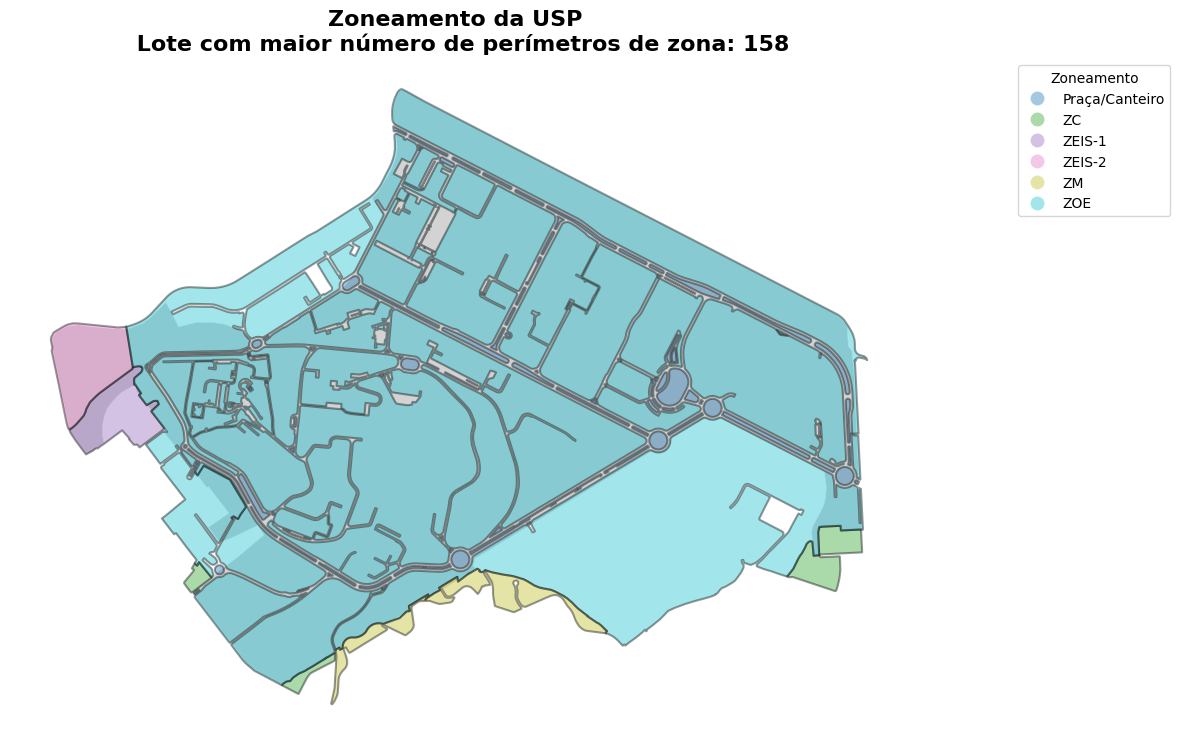

In [79]:
fig, ax = plt.subplots(figsize=(12, 10))

gdf_lote_usp.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)

ax.set_title(f"Zoneamento da USP \n Lote com maior número de perímetros de zona: {qtd_perimetros_sql_com_mais_perimetros}", fontsize=16, fontweight='bold')
gdf_perimetros_usp.plot(
    ax=ax, 
    column='cd_zoneamento_perimetro', 
    categorical=True, 
    legend=True, 
    alpha=0.4, 
    edgecolor='black', 
    linewidth=1.5,
    legend_kwds={'title': "Zoneamento", 'bbox_to_anchor': (1.3, 1)}
)

ax.set_axis_off()
plt.tight_layout()
save_img("zoneamento_da_usp.png", fig)
plt.show()

In [80]:
gdf_perimetros_usp['cd_zoneamento_perimetro'].value_counts()

cd_zoneamento_perimetro
Praça/Canteiro    115
ZOE                36
ZC                  4
ZEIS-1              1
ZEIS-2              1
ZM                  1
Name: count, dtype: int64

Mas olhando a USP vemos que em vários casos a interseccção é muito pequena, quase que uma "linha" só conflitando.

Vamos identificar esses casos ao identificar os sqls cuja interseccção mínima com perímetros de zoneamento é correspondente a 0% da área do lote.

In [81]:
duplicados_por_sql.head()

,sql,count,mean,min,max
0,001.001.0002,2,50.00,31.3,68.7
1,001.001.0003,5,13.54,4.1,28.8
2,001.003.0000,4,100.00,100.0,100.0
3,001.003.0001,2,100.00,100.0,100.0
4,001.004.0000,5,100.00,100.0,100.0


In [82]:
prop_sql_com_perimetros_interseccao_irrisoria = float((duplicados_por_sql['min']==0).mean())
metricas_dashboard['percent_sql_com_zonas_interseccao_irrisoria'] = round(prop_sql_com_perimetros_interseccao_irrisoria, 2)*100
metricas_dashboard

{'percent_lotes_mais_um_zona': 5.49,
 'qtd_perimetros_zonas_sql_com_mais_zonas': 158,
 'percent_sql_com_zonas_interseccao_irrisoria': 50.0}

Vamos avançar nas métricas e calcular a média de zonas por sql, para os sql que tem mais de uma zona

In [88]:
media_perimetros_por_sql = round(float(duplicados_por_sql['count'].mean()), 1)
metricas_dashboard['media_de_zonas_por_sql'] = media_perimetros_por_sql
metricas_dashboard


{'percent_lotes_mais_um_zona': 5.49,
 'qtd_perimetros_zonas_sql_com_mais_zonas': 158,
 'percent_sql_com_zonas_interseccao_irrisoria': 50.0,
 'media_de_zonas_por_sql': 2.3}

In [89]:
mediana_perimetros_por_sql = round(float(duplicados_por_sql['count'].median()), 1)
metricas_dashboard['mediana_de_zonas_por_sql'] = mediana_perimetros_por_sql
metricas_dashboard


{'percent_lotes_mais_um_zona': 5.49,
 'qtd_perimetros_zonas_sql_com_mais_zonas': 158,
 'percent_sql_com_zonas_interseccao_irrisoria': 50.0,
 'media_de_zonas_por_sql': 2.3,
 'mediana_de_zonas_por_sql': 2.0}